# 01. SHAP Explanations

## 📚 Learning Objectives

By completing this notebook, you will:
- Use SHAP for model interpretability
- Interpret feature attributions and plots
- Communicate model behavior to stakeholders

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 05 "Model Interpretability: SHAP and LIME" — you already ran SHAP on a tumour classifier there; what is new here is using the explanation as evidence in an ethical argument.

**Used later in:** Course 08 (AIAT 122) — Unit 4, lesson 04 "Ethical Concerns: Bias, Fairness, Interpretability" — the same demand made of a deep model.

---


# 01. SHAP Explanations

## 🚨 THE PROBLEM: AI Systems Are "Black Boxes"

**Remember the transition from Unit 3?**

We completed Unit 3: Privacy and Security, where we learned:
- How to protect data and ensure privacy
- How to comply with regulations
- How to build secure AI systems

**But there's a new challenge:**

**AI systems also raise transparency and accountability concerns!**

**The Problem**: As we build AI systems, we need to consider:
- ❌ **Transparency**: How do we explain AI decisions?
- ❌ **Accountability**: Who is responsible for AI outcomes?
- ❌ **Explainability**: How do we make AI understandable?
- ❌ **Auditability**: How do we track and verify AI behavior?

**We've learned:**
- ✅ How to build private and secure AI systems (Unit 3)
- ✅ How to ensure GDPR compliance
- ✅ How to protect data

**What you already learned in Course 01 (AIAT 111) — Unit 3, lesson 05 "Model Interpretability: SHAP and LIME":**
- ✅ How to run SHAP on a trained classifier and read its global and local output
- ✅ That a correct prediction tells you nothing about the model's reasoning

**What you have NOT done yet:**
- ❌ Use an explanation as **evidence in an ethical argument**, not as a debugging aid
- ❌ Check an explanation against an **independent fairness audit** of the same model
- ❌ State what an explanation **cannot** settle, so it is not oversold to a regulator or to
  the person the decision was made about

**We need explainability techniques** to:
1. Explain individual predictions (local explanations)
2. Understand overall model behavior (global explanations)
3. Identify important features
4. Make AI decisions transparent

**This notebook closes that gap.** You already know how to *produce* a SHAP explanation (Course 01, Unit 3, lesson 05). Here you learn to *use* one: on a model built from a real historical record, against a fairness finding you can check it with, for an audience entitled to an answer.

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Unit 1: Ethics Foundations** - Understanding ethical principles
- ✅ **Unit 2: Bias and Justice** - Understanding fairness
- ✅ **Unit 3: Privacy and Security** - Understanding privacy and security
- ✅ **Basic Python knowledge**: Functions, data manipulation, ML concepts
- ✅ **Basic ML knowledge**: Model training, predictions, feature importance

**If you haven't completed these**, you might struggle with:
- Understanding why explainability matters
- Knowing how to interpret model predictions
- Understanding feature importance concepts

---

## 🔗 Where This Notebook Fits

**This is the FIRST example in Unit 4** - it teaches you how to explain AI decisions!

**Why this example FIRST?**
- **Before** you can use other explanation methods, you need to understand SHAP
- **Before** you can ensure accountability, you need explainability
- **Before** you can build transparent systems, you need explanation techniques

**Builds on**: 
- 📓 Unit 1: Ethics Foundations (ethical principles)
- 📓 Unit 2: Bias and Justice (fairness concepts)
- 📓 Unit 3: Privacy and Security (privacy and security)

**Leads to**: 
- 📓 Example 2: LIME Explanations (alternative explanation method)
- 📓 Example 3: Counterfactual Analysis (what-if explanations)
- 📓 Example 4: Accountability Frameworks (accountability structures)
- 📓 Example 5: Human-in-the-Loop (HITL approaches)
- 📓 Example 6: Transparency Tools (transparency frameworks)

**Why this order?**
1. SHAP provides **foundation** for explainability (needed before other methods)
2. SHAP teaches **feature importance** (critical for understanding)
3. SHAP shows **local and global explanations** (essential for transparency)

---

## The Story: Opening the Black Box

Imagine you're a doctor using AI to diagnose patients. **Before** explainability, you'd get a diagnosis but wouldn't know why (black box!). **After** using SHAP, you can see which symptoms most influenced the diagnosis - transparent and understandable!

Same with AI: **Before** we have models that make predictions but we can't explain why, now we learn SHAP - calculate feature contributions to understand each prediction! **After** SHAP, we can explain why models make specific decisions!

---

## Why SHAP Explanations Matter

SHAP explanations are essential for ethical AI:
- **Transparency**: Understand why models make decisions
- **Trust**: Build user confidence through explanations
- **Debugging**: Identify model errors and biases
- **Compliance**: Meet explainability requirements
- **Accountability**: Enable responsibility for AI outcomes

## Learning Objectives
1. Understand SHAP values and their meaning
2. Learn how to calculate SHAP values
3. Generate local explanations for individual predictions
4. Generate global explanations for overall model behavior
5. Visualize SHAP explanations
6. Interpret SHAP results

## 📌 The case: a European court decided that the score owes you an explanation

**Case C-634/21, SCHUFA Holding ("Scoring"), Court of Justice of the EU, 7 December 2023.**

SCHUFA is Germany's largest credit reference agency. An applicant, OQ, was refused credit by
a third party that had drawn on a SCHUFA score. SCHUFA's defence was the one every scoring
vendor has always given: *we do not make decisions — we output a number, and a human
decides*.

The Court rejected it. Where a third party **draws strongly on** an automatically produced
score to grant or refuse a contract, producing that score is itself an **automated individual
decision under GDPR Article 22(1)** — and the duties attach to the **organisation that
computed the score**, not merely to the bank that acted on it. Those duties include giving
the data subject meaningful information about the **logic involved**.

That is the room this notebook is training you for. Somebody has been refused something, and
"the model decided" is now, in law, your problem rather than the caseworker's.

**The WHY — what goes wrong without explanation.** A model with no explanation cannot be
debugged, cannot be contested, and cannot be defended. You will not know whether it works for
the right reason or for a reason that will collapse next quarter; the affected person cannot
challenge a number they cannot see inside; and you cannot answer a regulator. SHAP does not
tell you a model is *good*. It tells you what the model is **doing** — and this notebook's
result is a demonstration of why that matters, because the strongest driver of our survival
model turns out to be a protected attribute that nobody programmed in.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `../../../Course 04/datasets/raw/titanic.csv` - 891 real passengers. Six real,
  interpretable features (`Pclass`, `Age`, `SibSp`, `Parch`, `Fare`, `is_female`)
  and the real recorded outcome, `Survived`.
- This is deliberately the same model Unit 2 audited for fairness, so the
  explanations here can be checked against those findings.

**Outputs:** What you'll see when you run the cells

- Global SHAP importance: which real attribute the model leans on most
- A local SHAP explanation for one real passenger, with their real record shown
- The ethical reading of that ranking, checked against the Unit 2 fairness audit

---

## Part 1: A Model to Explain

SHAP needs a model, so we first train a survival classifier on the **real Titanic
manifest** - a black box that owes people an explanation, built on a decision that
really happened. Then we compute **SHAP values**: each feature's contribution
(positive or negative) to one specific prediction, based on Shapley values from
game theory.

Using real data here is not decoration. With a dataset we invented, SHAP would
simply recover the formula we wrote - a circular exercise. With real data, SHAP
tells us something we did not already know, and we have to be willing to hear it.

In [1]:
# Why start here: explanation tools need a real trained model to interrogate.
# We train on the REAL Titanic manifest - real people, a real recorded outcome -
# so the explanations we produce are statements about the world, not about a
# formula we wrote ourselves.

# Build the real dataset and train the model we will explain
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv('../../../Course 04/datasets/raw/titanic.csv')
# Real missing values, handled openly: 177 ages and 2 ports are genuinely absent.
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Six interpretable features. Every one is a real recorded attribute of a real
# passenger - which is what makes an explanation of this model meaningful.
X = pd.DataFrame({
    'Pclass':    df['Pclass'].astype(float),      # ticket class: 1 = first, 3 = third
    'Age':       df['Age'].astype(float),         # years (median-imputed where missing)
    'SibSp':     df['SibSp'].astype(float),       # siblings/spouse aboard
    'Parch':     df['Parch'].astype(float),       # parents/children aboard
    'Fare':      df['Fare'].astype(float),        # ticket price paid
    'is_female': (df['Sex'] == 'female').astype(float),   # 1 = female, 0 = male
})
y = df['Survived'].values                          # 1 = survived, 0 = died

# Hold out a test set, then fit the classifier we will explain.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)
print(f"Real passengers: {len(df)}   (train {len(X_train)} / test {len(X_test)})")
print(f"Survival-prediction model trained. Test accuracy: "
      f"{accuracy_score(y_test, model.predict(X_test)):.3f}")
print(f"Real survival rate in the data: {y.mean():.1%}")
print(f"Real survival rate by sex: female {df[df.Sex=='female'].Survived.mean():.1%}, "
      f"male {df[df.Sex=='male'].Survived.mean():.1%}")
print("\nThis is the model Unit 2 audited. Now we ask it to explain itself -")
print("and we will see whether its explanation matches what the audit found.")

Real passengers: 891   (train 668 / test 223)
Survival-prediction model trained. Test accuracy: 0.789
Real survival rate in the data: 38.4%
Real survival rate by sex: female 74.2%, male 18.9%

This is the model Unit 2 audited. Now we ask it to explain itself -
and we will see whether its explanation matches what the audit found.


Global feature importance (mean |SHAP value|):
  is_female       0.2040
  Fare            0.0910
  Pclass          0.0865
  Age             0.0634
  SibSp           0.0292
  Parch           0.0201


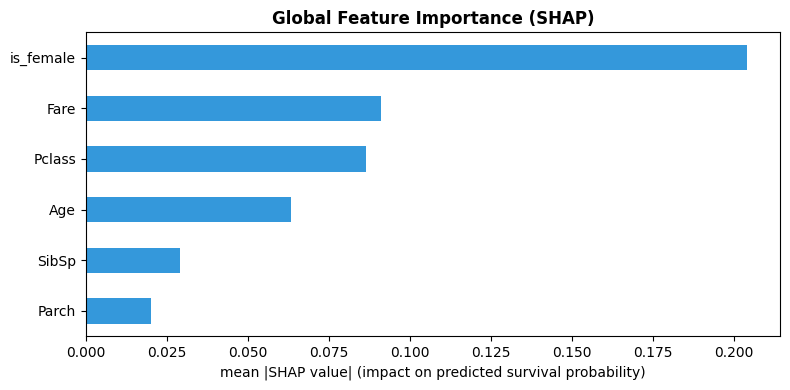


The model's most influential feature is 'is_female' (0.2040),
2.2x the next one ('Fare', 0.0910).

⚠️  READ THAT AGAIN. The single strongest driver of this model's
   predictions is the passenger's SEX - a protected attribute. Nobody
   programmed that rule; SHAP recovered it from what the model learned
   out of the historical record.

   This is the real value of explanation in an ethics course: SHAP did
   not tell us the model is broken. It told us WHAT the model is doing,
   and now a human has to decide whether a system that decides mainly on
   sex is acceptable for the purpose at hand. Unit 2 measured the same
   dependency from the outside as a fairness disparity; SHAP shows it
   from the inside. The two views agree.

Passenger #0: predicted survival probability 0.08 (actually died)
Pclass        3.00
Age          30.00
SibSp         0.00
Parch         0.00
Fare          8.05
is_female     0.00

SHAP contributions for THIS prediction (+ pushes toward survival):
  is_female  

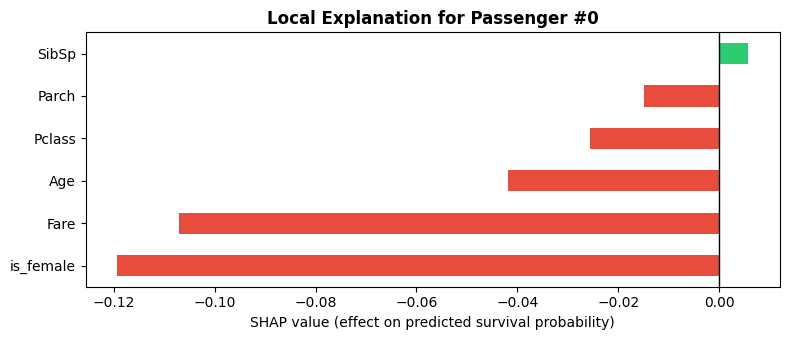


Reading it: green bars pushed this passenger toward a survival
prediction, red bars away from it. SHAP values are additive - they sum
(with the base rate) to the model's output for this passenger.
For this individual the dominant factor was 'is_female' (-0.1193).

Notice what a local explanation can and cannot do. It tells this person
WHY the model decided as it did. It does not tell them what to do about
it - that is the counterfactual question, in Notebook 03.


In [2]:
# Why SHAP: it assigns each feature a fair, additive share of the prediction
# (Shapley values from game theory) - one method gives global AND local views.

# Step 2: Compute SHAP values - global and local explanations
import shap
import matplotlib.pyplot as plt

# TreeExplainer computes exact Shapley values efficiently for tree ensembles.
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_test)
# Normalize across shap versions: get values for class 1 ("survived")
if isinstance(sv, list):
    sv1 = sv[1]
elif sv.ndim == 3:
    sv1 = sv[:, :, 1]
else:
    sv1 = sv

# --- GLOBAL explanation: mean |SHAP| per feature ---
importance = pd.Series(np.abs(sv1).mean(axis=0), index=X_test.columns
                       ).sort_values()
print("Global feature importance (mean |SHAP value|):")
for feat, val in importance.sort_values(ascending=False).items():
    print(f"  {feat:<15} {val:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot.barh(ax=ax, color='#3498db')
ax.set_xlabel('mean |SHAP value| (impact on predicted survival probability)')
ax.set_title('Global Feature Importance (SHAP)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# The ethical reading of the global chart - computed, not assumed.
ranked = importance.sort_values(ascending=False)
top_feature, top_value = ranked.index[0], ranked.iloc[0]
second_feature, second_value = ranked.index[1], ranked.iloc[1]
print(f"\nThe model's most influential feature is '{top_feature}' "
      f"({top_value:.4f}),")
print(f"{top_value/second_value:.1f}x the next one ('{second_feature}', "
      f"{second_value:.4f}).")
if top_feature == 'is_female':
    print("\n⚠️  READ THAT AGAIN. The single strongest driver of this model's")
    print("   predictions is the passenger's SEX - a protected attribute. Nobody")
    print("   programmed that rule; SHAP recovered it from what the model learned")
    print("   out of the historical record.")
    print("\n   This is the real value of explanation in an ethics course: SHAP did")
    print("   not tell us the model is broken. It told us WHAT the model is doing,")
    print("   and now a human has to decide whether a system that decides mainly on")
    print("   sex is acceptable for the purpose at hand. Unit 2 measured the same")
    print("   dependency from the outside as a fairness disparity; SHAP shows it")
    print("   from the inside. The two views agree.")

# --- LOCAL explanation: why was passenger #0 predicted this way? ---
i = 0
passenger = X_test.iloc[i]
proba = model.predict_proba(X_test.iloc[[i]])[0, 1]
print(f"\n{'='*70}")
print(f"Passenger #{i}: predicted survival probability {proba:.2f} "
      f"(actually {'survived' if y_test[i] == 1 else 'died'})")
print(passenger.round(2).to_string())
contrib = pd.Series(sv1[i], index=X_test.columns).sort_values()
print("\nSHAP contributions for THIS prediction (+ pushes toward survival):")
for feat, val in contrib.sort_values(key=abs, ascending=False).items():
    print(f"  {feat:<15} {val:+.4f}")

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in contrib]
contrib.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('SHAP value (effect on predicted survival probability)')
ax.set_title(f'Local Explanation for Passenger #{i}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

biggest = contrib.abs().idxmax()
print(f"\nReading it: green bars pushed this passenger toward a survival")
print(f"prediction, red bars away from it. SHAP values are additive - they sum")
print(f"(with the base rate) to the model's output for this passenger.")
print(f"For this individual the dominant factor was '{biggest}' "
      f"({contrib[biggest]:+.4f}).")
print("\nNotice what a local explanation can and cannot do. It tells this person")
print("WHY the model decided as it did. It does not tell them what to do about")
print("it - that is the counterfactual question, in Notebook 03.")

## 💬 Discuss

Your own run: global mean |SHAP| ranks **`is_female` at 0.2040**, which is **2.2×** the next
feature (`Fare`, 0.0910). For the individual passenger, `is_female` contributed **−0.1193**
toward a predicted survival probability of **0.08**. Nobody wrote that rule; SHAP recovered
it from what the model learned.

1. **You now know what the model is doing. What do you do?** SHAP has told you the top driver
   is sex. It has *not* told you that is wrong — on this data, sex genuinely predicts the
   recorded outcome. Under Unit 2's audit the same dependency showed up as a disparity from
   the outside. So: do you ship a model whose main input is a protected attribute, on the
   grounds that it is accurate and honest about it? Would your answer change if the decision
   were lifeboat places, insurance pricing, or a job? Name what changes across those three.
2. **Does this satisfy SCHUFA?** "Meaningful information about the logic involved" — is a
   SHAP bar chart it? Try writing the actual sentence you would send to the person refused:
   plain language, no jargon, accurate about a random forest. Then ask whether your sentence
   is something they can *act* on, and what it would take to make it so (that is Notebook 03).
3. **What if the explanation is the thing being sold?** Slack et al. (2020) built classifiers
   that are extremely biased *and* produce innocuous LIME and SHAP explanations on demand
   (Notebook 07 runs the idea). If explanations can be engineered, what makes an explanation
   trustworthy — the method, the auditor, or the fact that an independent party ran it on
   data the vendor did not choose? Say what you would require in a contract.


---

## 🚫 When SHAP Explanations Hit a Limitation

### The Limitation We Discovered

We've learned SHAP for explaining model predictions. **But there's still a challenge:**

**What if we need a simpler, faster explanation method that works with any model?**

SHAP works well when:
- ✅ We need mathematically rigorous explanations
- ✅ We can afford computational cost
- ✅ We want feature importance based on game theory

**But sometimes we need:**
- ❌ **Faster explanations** (SHAP can be slow for large datasets)
- ❌ **Simpler methods** (easier to understand and implement)
- ❌ **Model-agnostic approaches** (work with any black-box model)
- ❌ **Local explanations** (explain individual predictions quickly)

### Why This Is a Problem

When SHAP is too slow or complex:
- We may need faster explanations for real-time systems
- We may want simpler methods for non-technical users
- We may need alternatives for different use cases
- We may want to compare different explanation methods

### The Solution: LIME Explanations

We need **LIME (Local Interpretable Model-agnostic Explanations)** to:
1. Provide fast local explanations
2. Work with any black-box model
3. Offer simpler, more intuitive explanations
4. Enable real-time explainability

**This is exactly what we'll learn in the next notebook: LIME Explanations!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to use SHAP for model explanations
- ✅ How to generate local and global explanations
- ✅ **The limitation**: We need faster, simpler alternatives!

**Next notebook**: `02_lime_explanations.ipynb`
- Learn about LIME for fast local explanations
- Understand model-agnostic explainability
- Compare SHAP vs LIME approaches

## ⚠️ Where this breaks

- **SHAP explains the model, not the world.** A SHAP value says how a feature moved *this
  model's* output. It is not a causal claim about survival, credit-worthiness or health.
  Reading attributions as causes is the single most common misuse, and Notebook 03 shows what
  it costs when you turn one into advice.
- **Correlated features share credit arbitrarily.** `Fare` and `Pclass` are strongly related
  here, and the standard (interventional/marginal) SHAP computation splits their contribution
  in a way that depends on the estimation choice. Two defensible SHAP configurations can rank
  your features differently, so never present the ordering of adjacent, correlated features
  as a finding.
- **Global importance is an average, and averages hide subgroups.** A mean |SHAP| of 0.204 for
  `is_female` says nothing about whether the model relies on sex *more* for third-class
  passengers than for first. Disaggregate the explanation the same way Unit 2 disaggregates
  the metric, or you will reproduce the *Gender Shades* mistake one level up.
- **Explanation is not exoneration — and it can be actively engineered.** Slack et al. (2020)
  demonstrated scaffolded classifiers that hide extreme bias from both LIME and SHAP. An
  explanation produced by the vendor, on data chosen by the vendor, is a marketing artefact.
- **Exactness and cost.** `TreeExplainer` is exact and fast for tree ensembles, which is why
  this notebook is instant. `KernelExplainer` on an arbitrary model is an approximation with a
  sampling budget, and it is slow enough that people quietly cut the sample size and stop
  reporting that they did.
- **An explanation nobody reads is not transparency.** A bar chart handed to a caseworker who
  has 90 seconds per file changes nothing. Unit 4's later notebooks exist because the artefact
  has to reach a person who can act.

**The cheaper alternative:** if the decision is high-stakes and the tabular data is modest,
consider fitting an **inherently interpretable model** — a scored decision list, a small
tree, a GAM — instead of explaining a black box after the fact. The accuracy gap on tabular
problems is often small, and the explanation is then the model itself rather than an
approximation of it that someone can attack.


## 📚 References

1. Shapley, L. S. (1953). *A Value for n-Person Games*. In: Contributions to the Theory of Games II. Princeton University Press. (the game-theoretic foundation)
2. Lundberg, S. M. & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS 2017. <https://arxiv.org/abs/1705.07874>
3. Slack, D., Hilgard, S., Jia, E., Singh, S. & Lakkaraju, H. (2020). *Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods*. AIES 2020. <https://arxiv.org/abs/1911.02508>
4. Molnar, C. *Interpretable Machine Learning: A Guide for Making Black Box Models Explainable* (online book). <https://christophm.github.io/interpretable-ml-book/>